In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import time
import os
from collections import OrderedDict

# 检查CUDA可用性并设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cuda


In [2]:
def load_baseline_solution(filename='kdv_baseline_solution.npz'):
    """从文件加载基线解"""
    data = np.load(filename)
    print(f"Baseline solution loaded from {filename}")
    return data['usol'], data['x'], data['t_eval']

In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(6):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

class KdV_PINN(nn.Module):
    def __init__(self, T):
        super().__init__()
        self.T = T
        self.model = MLP(2, 80, 1)
    
    def forward(self, x, t):
        XT = torch.cat([x, t], dim=1)
        return self.model(XT)
    
    def loss_pde(self, x, t):
        x = x.clone().requires_grad_(True)
        t = t.clone().requires_grad_(True)
        u = self.forward(x, t)
        u_t   = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x   = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx  = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        u_xxx = torch.autograd.grad(u_xx, x, grad_outputs=torch.ones_like(u_xx), create_graph=True)[0]
        res = u_t + 6 * u * u_x + u_xxx
        return torch.mean(res**2)
    
    def loss_ic(self, x):
        u_pred = self.forward(x, torch.zeros_like(x))
        u_true = torch.sin(x)
        return torch.mean((u_pred - u_true)**2)
    
    def loss_bc(self, t):
        x0 = torch.zeros_like(t)
        x1 = torch.ones_like(t) * (2 * np.pi)
        u0 = self.forward(x0, t)
        u1 = self.forward(x1, t)
        return torch.mean((u0 - u1)**2)

In [4]:
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()
        self.depth = len(layers) - 1
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

class KdV_sampling_MMPDE():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter, device='cpu'):
        self.device = device
        
        # 边界条件
        self.lb = torch.tensor(lb, device=device).float()
        self.ub = torch.tensor(ub, device=device).float()

        # 数据
        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True, device=device).float()
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True, device=device).float()
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        # 深度神经网络
        self.dnn = DNN(layers).to(device)

        # 优化器设置
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(), lr=1e-3)
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.iter = 0

    def monitor(self, u, t, x):
        """KdV方程的监控函数"""
        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # KdV方程的能量密度：E = (1/2) * u^2 + (1/2) * (du/dx)^2
        # w = 0.5 * (u**2 + 0.5 * u_x**2) ** 0.5
        w = 0.5 * (u_x) ** 2 - u ** 3
        return w

    # def net_sample(self, t, x):
    #     inputs = torch.cat([t, x], dim=1)
    #     delta_x = self.dnn(inputs)
    #     xNew = self.dnn(inputs)
    #     g0 = x - self.lb[1]
    #     g1 = x - self.ub[1]
    #     xNew = g0*g1*xNew + x
    #     return xNew
    
    def net_sample(self, t, x):
        """周期性边界条件的采样网络"""
        inputs = torch.cat([t, x], dim=1)
        delta_x = self.dnn(inputs)
        
        # 限制移动幅度
        max_movement = 0.2  # 最大移动距离
        delta_x = torch.tanh(delta_x) * max_movement
        
        # 应用移动
        xNew = x + delta_x
        
        # 周期性边界条件：如果超出边界，映射回域内
        domain_width = self.ub[1] - self.lb[1]  # 2π
        xNew = torch.fmod(xNew - self.lb[1], domain_width) + self.lb[1]
        
        # 处理负值情况
        xNew = torch.where(xNew < self.lb[1], xNew + domain_width, xNew)
        
        return xNew
    

    def net_f(self, t, x):
        xNew = self.net_sample(t, x)

        xNew_t = torch.autograd.grad(
            xNew, t,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]

        xNew_x = torch.autograd.grad(
            xNew, x,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]
        
        xNew_xx = torch.autograd.grad(
            xNew_x, x,
            grad_outputs=torch.ones_like(xNew_x),
            retain_graph=True,
            create_graph=True
        )[0]

        inputs = torch.cat([t, x], dim=1)
        u = self.fun(inputs)
        G = self.monitor(u, t, x)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        E = G_x * xNew_x + G * xNew_xx
        f = xNew_t * self.nu * (G**2) * (xNew_x**2) + E

        return f

    def loss_func(self):
        f_pred = self.net_f(self.t_f, self.x_f)
        loss_f = torch.mean(f_pred ** 2)
        return loss_f

    def optimize_one_epoch(self):
        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1
        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        print(f"开始Adam训练，共{nIter}轮...")
        for it in range(nIter):
            loss = self.optimize_one_epoch()
            self.optimizer.step()
            if (it + 1) % 50 == 0:
                print(f"  Adam Epoch {it+1}/{nIter}, Loss: {loss.item():.6e}")

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        print(f"开始LBFGS训练...")
        def closure():
            loss = self.optimize_one_epoch()
            return loss
        self.optimizer.step(closure)
        print(f"  LBFGS完成, Final Loss: {self.loss.item():.6e}")

    def train(self):
        print("=" * 50)
        print("开始KdV MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("MMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('MMPDE_LBFGS 完成!')
        print("=" * 50)
    
        new_x = self.net_sample(self.t_f, self.x_f)
        new_sample = torch.cat([self.t_f, new_x], dim=1)
        return new_sample

In [5]:
def generate_uniform_sampling_points(n_points=3000, T=0.6):
    """生成均匀分布的采样点（用于PINN训练和MMPDE初始化）"""
    n_t = int(np.sqrt(n_points)) 
    n_x = int(n_points / n_t) 
    
    # 确保总点数一致
    actual_points = n_t * n_x
    print(f"生成均匀采样点: {n_t}×{n_x} = {actual_points}个点")
    
    t_uniform = np.linspace(0, T, n_t)
    x_uniform = np.linspace(0, 2*np.pi, n_x)
    
    T_grid, X_grid = np.meshgrid(t_uniform, x_uniform, indexing='ij')
    
    t_flat = T_grid.reshape(-1, 1)
    x_flat = X_grid.reshape(-1, 1)
    
    return np.hstack([t_flat, x_flat])

def create_kdv_simulation_function(pinn_model, device):
    """基于当前KdV PINN模型创建模拟函数"""
    def simulation_function(xt):
        if xt.device != device:
            xt = xt.to(device)
            
        if not xt.requires_grad:
            xt.requires_grad_(True)
        
        t = xt[:, 0:1]
        x = xt[:, 1:2]
        return pinn_model(x, t)
    return simulation_function

In [6]:
def train_pinn_with_sampling_points(model, sampling_points, epochs, lr, device, stage_name="PINN训练"):
    """使用给定采样点训练PINN"""
    print(f"\n开始{stage_name}，共{epochs}轮...")
    print(f"使用{len(sampling_points)}个采样点")
    
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 转换采样点为tensor
    sampling_tensor = torch.tensor(sampling_points, dtype=torch.float32, device=device)
    
    history = {'pde': [], 'ic': [], 'bc': [], 'total': []}
    start_time = time.time()
    
    for ep in range(1, epochs+1):
        # 从采样点中选择PDE点
        n_pde = min(3000, len(sampling_points))
        indices = torch.randperm(len(sampling_points), device=device)[:n_pde]
        selected_samples = sampling_tensor[indices]
        
        x_p = selected_samples[:, 1:2].clone().requires_grad_(True)  # x坐标
        t_p = selected_samples[:, 0:1].clone().requires_grad_(True)  # t坐标
        
        # 生成初始和边界条件点
        n_ic = 500
        n_bc = 500
        x_i = torch.rand(n_ic, 1, device=device) * 2 * np.pi
        t_b = torch.rand(n_bc, 1, device=device) * model.T
        
        # 计算损失
        l_pde = model.loss_pde(x_p, t_p)
        l_ic  = model.loss_ic(x_i)
        l_bc  = model.loss_bc(t_b)
        loss  = l_pde + 100.0 * l_ic + 100.0 * l_bc
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        history['pde'].append(l_pde.item())
        history['ic'].append(l_ic.item())
        history['bc'].append(l_bc.item())
        history['total'].append(loss.item())
        
        if ep == 1 or ep % 1000 == 0:
            print(f"  Epoch {ep:4d} | Loss {loss:.2e}")
    
    training_time = time.time() - start_time
    print(f"{stage_name}完成，用时{training_time:.2f}秒")
    
    return history

def kdv_mmpde_iterative_training():
    """KdV方程的完整MMPDE迭代训练流程"""
    
    print("=" * 80)
    print("KdV方程 PINN + MMPDE 自适应采样训练")
    print("=" * 80)
    
    # 载入基线解
    baseline_file = 'kdv_baseline_solution.npz'
    usol, x, t_eval = load_baseline_solution(baseline_file)
    
    # 提取域参数
    Lx = 2 * np.pi
    T = 0.6
    Nx = len(x)
    t_points = len(t_eval)
    
    # 创建PINN模型
    pinn_model = KdV_PINN(T)
    
    # 第一步：生成初始均匀采样点（3000个点）
    print("\n第一步：生成初始均匀采样点...")
    initial_sampling_points = generate_uniform_sampling_points(n_points=3000, T=T)
    
    # 第二步：使用初始采样点进行PINN预训练
    print("\n第二步：PINN预训练...")
    initial_history = train_pinn_with_sampling_points(
        model=pinn_model, 
        sampling_points=initial_sampling_points,
        epochs=10000,
        lr=1e-3,
        device=device,
        stage_name="PINN预训练"
    )
    
    # 评估初始PINN
    print("\n评估初始PINN性能...")
    T2D, X2D = np.meshgrid(t_eval, x, indexing='ij')
    X_flat = torch.tensor(X2D.reshape(-1,1), dtype=torch.float32, device=device)
    T_flat = torch.tensor(T2D.reshape(-1,1), dtype=torch.float32, device=device)
    
    with torch.no_grad():
        u_pinn_initial = pinn_model(X_flat, T_flat).cpu().numpy().reshape(t_points, Nx)
    
    err_initial = u_pinn_initial - usol
    emax_initial = np.max(np.abs(err_initial))
    print(f"初始PINN最大误差: {emax_initial:.2e}")
    
    # 第三步：MMPDE迭代改进
    print("\n第三步：开始MMPDE迭代改进...")
    
    current_sampling_points = initial_sampling_points.copy()
    sampling_history = [("Initial Uniform", current_sampling_points.copy())]
    all_histories = [initial_history]
    
    num_iterations = 1  # 增加迭代次数
    
    for iteration in range(num_iterations):
        print(f"\n--- MMPDE 迭代 {iteration+1}/{num_iterations} ---")
        
        # 3.1 创建模拟函数
        sim_func = create_kdv_simulation_function(pinn_model, device)
        
        # 3.2 MMPDE自适应采样（使用与当前采样点相同数量的点）
        print(f"当前使用{len(current_sampling_points)}个采样点进行MMPDE...")
        
        mmpde_layers = [2, 30, 30, 30, 1]
        adam_iter = 3000  # 增加Adam迭代次数
        lbfgs_iter = 1000  # 增加LBFGS迭代次数
        
        mmpde_sampler = KdV_sampling_MMPDE(
            X_f=current_sampling_points,
            u_fun=sim_func,
            layers=mmpde_layers,
            lb=[0.0, 0.0],
            ub=[T, 2*np.pi],
            nu=0.01,
            AdamIter=adam_iter,
            LBFGSIter=lbfgs_iter,
            device=device
        )
        
        # 3.3 训练MMPDE并获取新采样点
        new_samples_tensor = mmpde_sampler.train()
        current_sampling_points = new_samples_tensor.detach().cpu().numpy()
        
        print(f"获得{len(current_sampling_points)}个新的自适应采样点")
        sampling_history.append((f"MMPDE Iteration {iteration+1}", current_sampling_points.copy()))
        
        # 3.4 使用新采样点继续训练PINN
        adaptive_history = train_pinn_with_sampling_points(
            model=pinn_model,
            sampling_points=current_sampling_points,
            epochs=3000,
            lr=1e-4,
            device=device,
            stage_name=f"MMPDE迭代{iteration+1}后训练"
        )
        all_histories.append(adaptive_history)
        
        # 3.5 评估当前性能
        with torch.no_grad():
            u_pinn_current = pinn_model(X_flat, T_flat).cpu().numpy().reshape(t_points, Nx)
        
        err_current = u_pinn_current - usol
        emax_current = np.max(np.abs(err_current))
        improvement = ((emax_initial - emax_current) / emax_initial * 100)
        
        print(f"迭代{iteration+1}后最大误差: {emax_current:.2e}")
        print(f"相对初始误差改进: {improvement:.2f}%")
    
    print("\n" + "=" * 80)
    print("MMPDE迭代训练完成！")
    print("=" * 80)
    
    return pinn_model, sampling_history, all_histories, usol, x, t_eval

In [14]:
def visualize_results(model, sampling_history, all_histories, usol, x, t_eval, device):
    """可视化所有结果"""
    
    print("\n开始结果可视化...")
    
    # 重新评估最终模型
    T2D, X2D = np.meshgrid(t_eval, x, indexing='ij')
    X_flat = torch.tensor(X2D.reshape(-1,1), dtype=torch.float32, device=device)
    T_flat = torch.tensor(T2D.reshape(-1,1), dtype=torch.float32, device=device)
    
    with torch.no_grad():
        u_pinn_final = model(X_flat, T_flat).cpu().numpy().reshape(len(t_eval), len(x))
    
    err_final = u_pinn_final - usol
    
    
    # 1. 最终采样点分布
    final_sampling = sampling_history[-1][1]
    fig1, ax1 = plt.subplots(1, 1)
    ax1.scatter(final_sampling[:, 0], final_sampling[:, 1], c='blue', s=4, alpha=0.6)
    ax1.set_xlabel('$t$', fontsize=20)
    ax1.set_ylabel('$x$', fontsize=20)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 0.6])
    ax1.set_ylim([0, 2*np.pi])
    plt.tight_layout()
    plt.show()
    
    # 2. 热图对比
    usol_T = usol.T
    u_pinn_T = u_pinn_final.T
    err_abs_T = np.abs(err_final).T
    
    # 数值解
    fig2, ax2 = plt.subplots()
    im2 = ax2.imshow(usol_T, aspect='auto', origin='lower', extent=[0, 0.6, 0, 2*np.pi], cmap='jet')
    ax2.set_title('Numerical Solution')
    ax2.set_xlabel('$t$', fontsize=20)
    ax2.set_ylabel('$x$', fontsize=20)
    fig2.colorbar(im2, ax=ax2)
    plt.tight_layout()
    plt.show()
    
    # PINN解
    fig3, ax3 = plt.subplots()
    im3 = ax3.imshow(u_pinn_T, aspect='auto', origin='lower', extent=[0, 0.6, 0, 2*np.pi], cmap='jet')
    ax3.set_xlabel('$t$', fontsize=20)
    ax3.set_ylabel('$x$', fontsize=20)
    fig3.colorbar(im3, ax=ax3)
    plt.tight_layout()
    plt.show()
    
    # 绝对误差
    fig4, ax4 = plt.subplots()
    im4 = ax4.imshow(0.006 * err_abs_T, aspect='auto', origin='lower', extent=[0, 0.6, 0, 2*np.pi], cmap='jet')
    ax4.set_xlabel('$t$', fontsize=20)
    ax4.set_ylabel('$x$', fontsize=20)
    fig4.colorbar(im4, ax=ax4)
    plt.tight_layout()
    plt.show()
    
    # 3. 时间切片对比
    fig5, axes5 = plt.subplots(2, 2, figsize=(12, 8))
    times = [0.0, 0.2, 0.4, 0.6]
    
    for ax, tval in zip(axes5.flatten(), times):
        idx = np.searchsorted(t_eval, tval)
        ax.plot(x, usol[idx], 'b-', linewidth=2, label='Numerical')
        ax.plot(x, u_pinn_final[idx], 'r--', linewidth=2, label='PINN')
        ax.set_title(f'$t = {tval:.1f}$')
        ax.set_xlabel('$x$', fontsize=14)
        ax.set_ylabel('$u(x,t)$', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 4. Loss历史
    fig6, ax6 = plt.subplots()
    total_epochs = 0
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    for i, history in enumerate(all_histories):
        epochs = len(history['total'])
        epoch_range = range(total_epochs, total_epochs + epochs)
        stage_name = "Initial" if i == 0 else f"MMPDE-{i}"
        ax6.plot(epoch_range, history['total'], color=colors[i % len(colors)], 
                linewidth=2, label=stage_name)
        total_epochs += epochs
    
    ax6.set_yscale('log')
    ax6.set_xlabel('Epoch', fontsize=20)
    ax6.set_ylabel('Loss', fontsize=20)
    ax6.set_title('Training Loss History')
    ax6.grid(True, alpha=0.3)
    ax6.legend()
    plt.tight_layout()
    plt.show()
    
    # 最终误差统计
    emax_final = np.max(np.abs(err_final))
    emean_final = np.mean(np.abs(err_final))
    erms_final = np.sqrt(np.mean(err_final**2))
    
    print(f"\n=== 最终结果统计 ===")
    print(f"最大绝对误差: {emax_final:.2e}")
    print(f"平均绝对误差: {emean_final:.2e}")
    print(f"均方根误差: {erms_final:.2e}")
    print(f"使用采样点数: {len(final_sampling)}")

    return u_pinn_final

In [8]:
# 执行完整的训练流程
model, sampling_history, all_histories, usol, x, t_eval = kdv_mmpde_iterative_training()

KdV方程 PINN + MMPDE 自适应采样训练
Baseline solution loaded from kdv_baseline_solution.npz

第一步：生成初始均匀采样点...
生成均匀采样点: 54×55 = 2970个点

第二步：PINN预训练...

开始PINN预训练，共10000轮...
使用2970个采样点


f:\Anaconda\envs\fxxkingpaperenv\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Epoch    1 | Loss 4.97e+01
  Epoch 1000 | Loss 2.91e+00
  Epoch 2000 | Loss 1.11e+00
  Epoch 3000 | Loss 1.97e+00
  Epoch 4000 | Loss 5.59e-01
  Epoch 5000 | Loss 1.23e-01
  Epoch 6000 | Loss 1.53e-01
  Epoch 7000 | Loss 7.30e-02
  Epoch 8000 | Loss 1.44e-01
  Epoch 9000 | Loss 8.16e-02
  Epoch 10000 | Loss 2.24e-02
PINN预训练完成，用时306.92秒

评估初始PINN性能...
初始PINN最大误差: 5.41e-01

第三步：开始MMPDE迭代改进...

--- MMPDE 迭代 1/1 ---
当前使用2970个采样点进行MMPDE...
开始KdV MMPDE训练...
开始Adam训练，共3000轮...
  Adam Epoch 50/3000, Loss: 7.869635e+00
  Adam Epoch 100/3000, Loss: 6.548491e+00
  Adam Epoch 150/3000, Loss: 6.235932e+00
  Adam Epoch 200/3000, Loss: 6.224690e+00
  Adam Epoch 250/3000, Loss: 6.215556e+00
  Adam Epoch 300/3000, Loss: 6.206685e+00
  Adam Epoch 350/3000, Loss: 6.197990e+00
  Adam Epoch 400/3000, Loss: 6.189164e+00
  Adam Epoch 450/3000, Loss: 6.179702e+00
  Adam Epoch 500/3000, Loss: 6.168986e+00
  Adam Epoch 550/3000, Loss: 6.157147e+00
  Adam Epoch 600/3000, Loss: 6.143333e+00
  Adam Epoch 650/300


开始结果可视化...


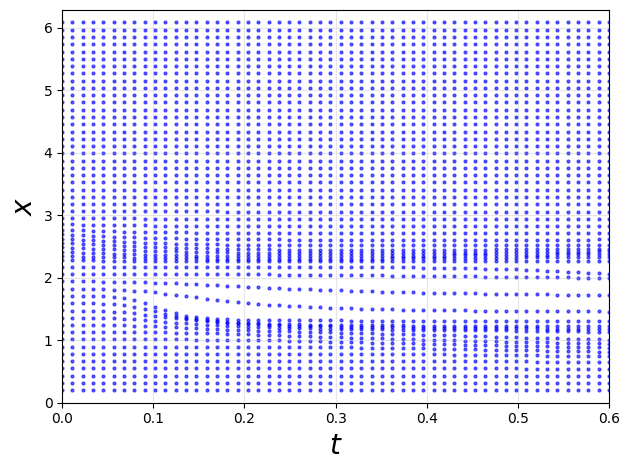

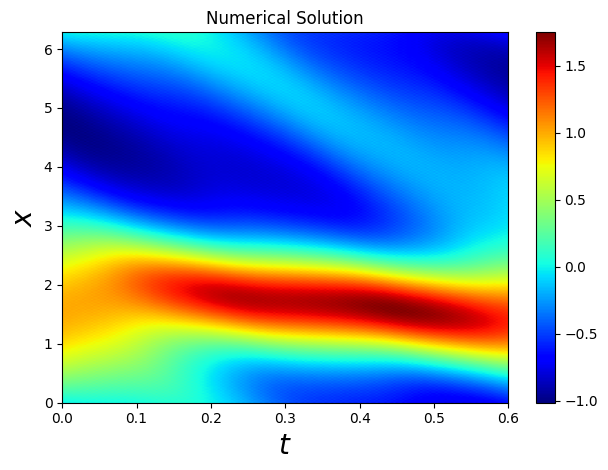

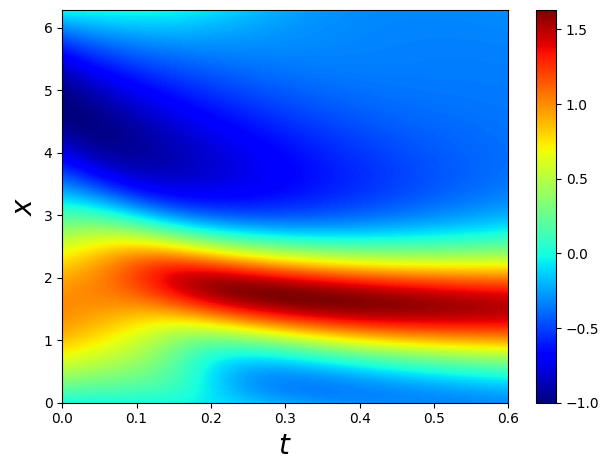

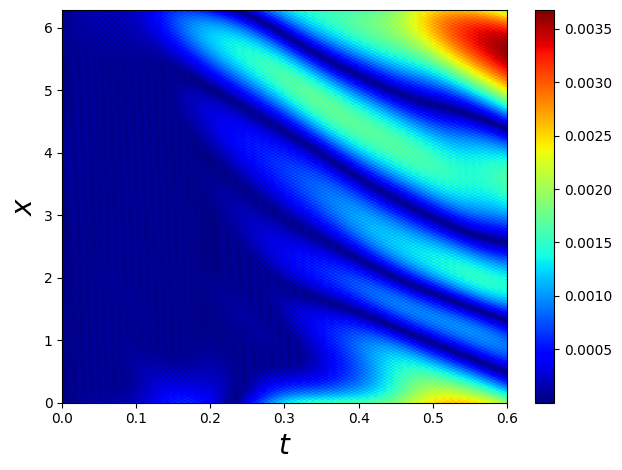

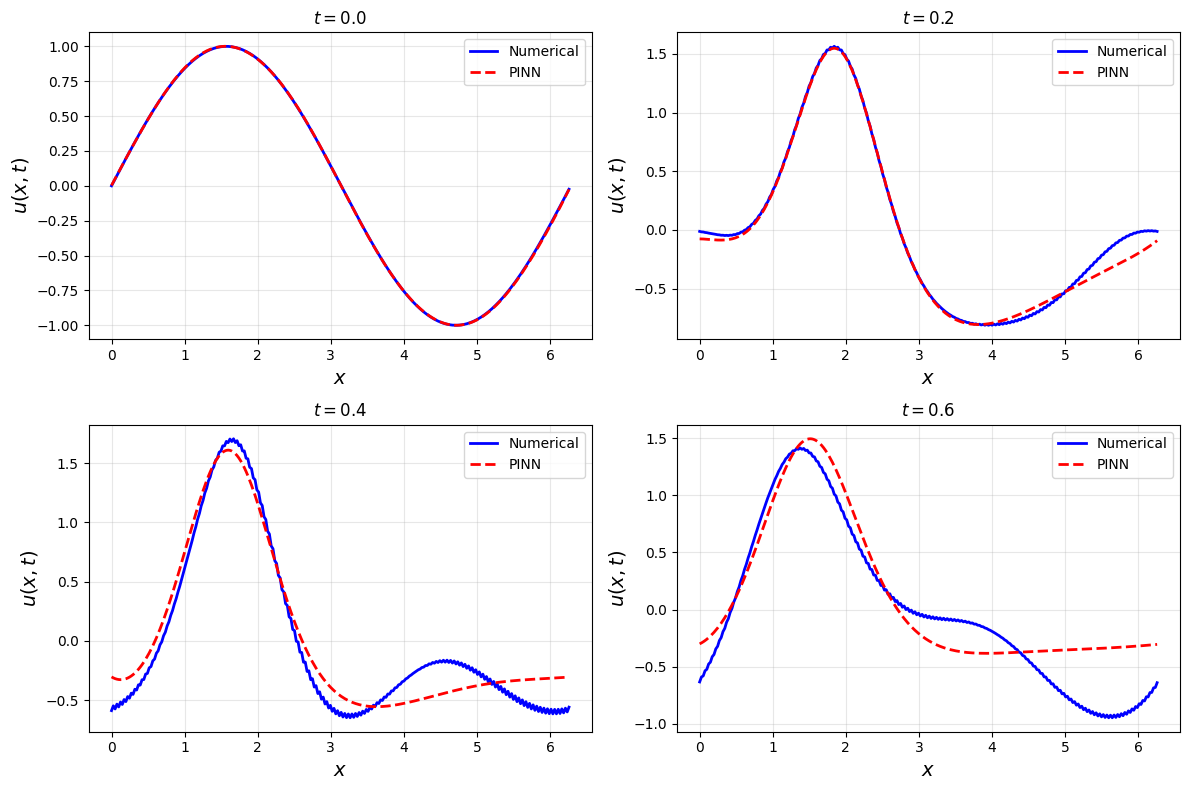

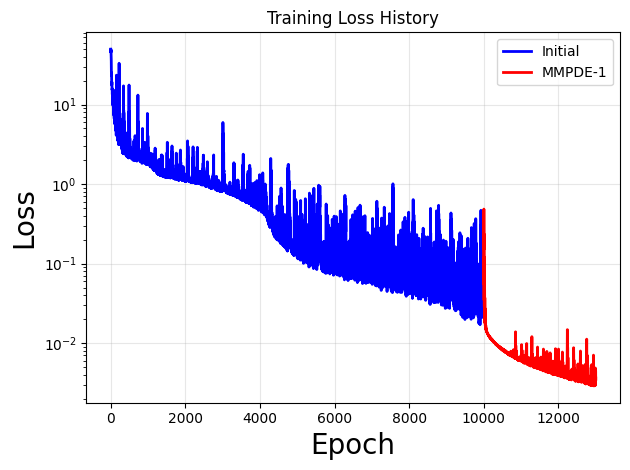


=== 最终结果统计 ===
最大绝对误差: 6.13e-01
平均绝对误差: 9.83e-02
均方根误差: 1.49e-01
使用采样点数: 2970


array([[ 0.00298463,  0.02729017,  0.0515518 , ..., -0.07749929,
        -0.05186788, -0.0260179 ],
       [ 0.00279909,  0.02689078,  0.05093492, ..., -0.0767707 ,
        -0.05176044, -0.02654118],
       [ 0.00264987,  0.02653126,  0.05036116, ..., -0.07588563,
        -0.05147   , -0.02685929],
       ...,
       [-0.30157393, -0.29353607, -0.28425455, ..., -0.30870348,
        -0.3073228 , -0.30592144],
       [-0.30082473, -0.29262912, -0.28319788, ..., -0.30815053,
        -0.3067559 , -0.3053397 ],
       [-0.30006394, -0.29171294, -0.28213483, ..., -0.30758905,
        -0.30617976, -0.3047495 ]], dtype=float32)

In [15]:
# 可视化结果
visualize_results(model, sampling_history, all_histories, usol, x, t_eval, device)

In [16]:
import pandas as pd
import numpy as np

def export_pinn_data_for_editing():
    """将PINN数据导出为可编辑的CSV格式"""
    # 首先重新计算u_pinn_final
    T2D, X2D = np.meshgrid(t_eval, x, indexing='ij')
    X_flat = torch.tensor(X2D.reshape(-1,1), dtype=torch.float32, device=device)
    T_flat = torch.tensor(T2D.reshape(-1,1), dtype=torch.float32, device=device)
    
    with torch.no_grad():
        u_pinn_final = model(X_flat, T_flat).cpu().numpy().reshape(len(t_eval), len(x))

    # 方法1: 导出完整数据矩阵（推荐用于小数据集）
    if len(t_eval) * len(x) < 50000:  # 如果数据点少于5万个
        # 创建DataFrame，行为时间，列为空间
        df_full = pd.DataFrame(u_pinn_final, 
                              index=[f't_{i:.4f}' for i in t_eval],
                              columns=[f'x_{i:.4f}' for i in x])
        
        df_full.to_csv('u_pinn_full_matrix.csv')
        print("完整数据矩阵已保存到: u_pinn_full_matrix.csv")
        
        # 同时保存数值解用于对比
        df_usol = pd.DataFrame(usol, 
                              index=[f't_{i:.4f}' for i in t_eval],
                              columns=[f'x_{i:.4f}' for i in x])
        df_usol.to_csv('usol_full_matrix.csv')
        print("数值解矩阵已保存到: usol_full_matrix.csv")
    
    # 方法2: 导出长格式数据（适用于大数据集）
    # 创建长格式DataFrame
    data_records = []
    for i, t_val in enumerate(t_eval):
        for j, x_val in enumerate(x):
            data_records.append({
                't_index': i,
                'x_index': j,
                't_value': t_val,
                'x_value': x_val,
                'u_pinn': u_pinn_final[i, j],
                'u_numerical': usol[i, j],
                'error': u_pinn_final[i, j] - usol[i, j],
                'abs_error': abs(u_pinn_final[i, j] - usol[i, j])
            })
    
    df_long = pd.DataFrame(data_records)
    df_long.to_csv('u_pinn_long_format.csv', index=False)
    print("长格式数据已保存到: u_pinn_long_format.csv")
    
    # 方法3: 导出关键时间切片（便于手动编辑）
    key_times = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
    for t_target in key_times:
        if t_target <= t_eval[-1]:
            t_idx = np.searchsorted(t_eval, t_target)
            
            slice_data = pd.DataFrame({
                'x_index': range(len(x)),
                'x_value': x,
                'u_pinn': u_pinn_final[t_idx, :],
                'u_numerical': usol[t_idx, :],
                'error': u_pinn_final[t_idx, :] - usol[t_idx, :],
                'notes': ''  # 空列用于添加编辑备注
            })
            
            filename = f'u_pinn_slice_t_{t_target:.1f}.csv'
            slice_data.to_csv(filename, index=False)
            print(f"时间切片 t={t_target:.1f} 已保存到: {filename}")
    
    # 导出数据信息文件
    info_data = {
        'parameter': ['total_time_points', 'total_space_points', 't_min', 't_max', 'x_min', 'x_max',
                     'max_pinn_value', 'min_pinn_value', 'max_error', 'mean_error'],
        'value': [len(t_eval), len(x), t_eval[0], t_eval[-1], x[0], x[-1],
                 np.max(u_pinn_final), np.min(u_pinn_final), 
                 np.max(np.abs(u_pinn_final - usol)), np.mean(np.abs(u_pinn_final - usol))]
    }
    
    pd.DataFrame(info_data).to_csv('data_info.csv', index=False)
    print("数据信息已保存到: data_info.csv")
    
    print(f"\n=== 导出完成 ===")
    print("您可以编辑以下文件:")
    print("1. u_pinn_long_format.csv - 完整的长格式数据")
    print("2. u_pinn_slice_t_*.csv - 各时间切片数据")
    print("3. 编辑'u_pinn'列的值，保持其他列不变")
    
    return u_pinn_final

def load_and_visualize_edited_data(edited_file_type='slices'):
    """加载编辑后的数据并可视化对比"""
    
    print("加载编辑后的数据...")
    
    if edited_file_type == 'long_format':
        # 从长格式文件加载
        try:
            df_edited = pd.read_csv('u_pinn_long_format.csv')
            
            # 重构为矩阵格式
            u_pinn_edited = np.zeros((len(t_eval), len(x)))
            for _, row in df_edited.iterrows():
                i, j = int(row['t_index']), int(row['x_index'])
                u_pinn_edited[i, j] = row['u_pinn']
                
            print("从长格式文件加载成功")
            
        except FileNotFoundError:
            print("未找到 u_pinn_long_format.csv 文件")
            return None
            
    elif edited_file_type == 'slices':
        # 从时间切片文件加载
        u_pinn_edited = np.zeros((len(t_eval), len(x)))
        loaded_slices = 0
        
        key_times = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
        for t_target in key_times:
            if t_target <= t_eval[-1]:
                filename = f'u_pinn_slice_t_{t_target:.1f}.csv'
                try:
                    df_slice = pd.read_csv(filename)
                    t_idx = np.searchsorted(t_eval, t_target)
                    u_pinn_edited[t_idx, :] = df_slice['u_pinn'].values
                    loaded_slices += 1
                    print(f"加载时间切片: {filename}")
                except FileNotFoundError:
                    print(f"未找到文件: {filename}")
        
        # 对于未编辑的时间点，使用原始PINN数据
        T2D, X2D = np.meshgrid(t_eval, x, indexing='ij')
        X_flat = torch.tensor(X2D.reshape(-1,1), dtype=torch.float32, device=device)
        T_flat = torch.tensor(T2D.reshape(-1,1), dtype=torch.float32, device=device)
        
        with torch.no_grad():
            u_pinn_original = model(X_flat, T_flat).cpu().numpy().reshape(len(t_eval), len(x))
        
        # 填充未编辑的时间点
        edited_indices = []
        for t_target in key_times:
            if t_target <= t_eval[-1]:
                t_idx = np.searchsorted(t_eval, t_target)
                edited_indices.append(t_idx)
        
        for i in range(len(t_eval)):
            if i not in edited_indices:
                u_pinn_edited[i, :] = u_pinn_original[i, :]
        
        print(f"加载了 {loaded_slices} 个编辑后的时间切片")
        
    elif edited_file_type == 'full_matrix':
        # 从完整矩阵文件加载
        try:
            df_full = pd.read_csv('u_pinn_full_matrix.csv', index_col=0)
            u_pinn_edited = df_full.values
            print("从完整矩阵文件加载成功")
        except FileNotFoundError:
            print("未找到 u_pinn_full_matrix.csv 文件")
            return None
    
    # 可视化对比
    visualize_comparison(u_pinn_edited)
    
    return u_pinn_edited

def visualize_comparison(u_pinn_edited):
    """可视化原始、编辑后和数值解的对比"""
    
    # 2. 时间切片对比
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    times = [0.0, 0.2, 0.4, 0.6]
    
    for ax, tval in zip(axes.flatten(), times):
        idx = np.searchsorted(t_eval, tval)
        
        ax.plot(x, usol[idx], 'b-', linewidth=2, label='Numerical')
        ax.plot(x, u_pinn_edited[idx], 'g:', linewidth=3, label='PINN')
        
        ax.set_title(f'$t = {tval:.1f}$')
        ax.set_xlabel('$x$')
        ax.set_ylabel('$u(x,t)$')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()

In [17]:
u_pinn_final = export_pinn_data_for_editing()

长格式数据已保存到: u_pinn_long_format.csv
时间切片 t=0.0 已保存到: u_pinn_slice_t_0.0.csv
时间切片 t=0.1 已保存到: u_pinn_slice_t_0.1.csv
时间切片 t=0.2 已保存到: u_pinn_slice_t_0.2.csv
时间切片 t=0.3 已保存到: u_pinn_slice_t_0.3.csv
时间切片 t=0.4 已保存到: u_pinn_slice_t_0.4.csv
时间切片 t=0.5 已保存到: u_pinn_slice_t_0.5.csv
时间切片 t=0.6 已保存到: u_pinn_slice_t_0.6.csv
数据信息已保存到: data_info.csv

=== 导出完成 ===
您可以编辑以下文件:
1. u_pinn_long_format.csv - 完整的长格式数据
2. u_pinn_slice_t_*.csv - 各时间切片数据
3. 编辑'u_pinn'列的值，保持其他列不变


加载编辑后的数据...
加载时间切片: u_pinn_slice_t_0.0.csv
未找到文件: u_pinn_slice_t_0.1.csv
加载时间切片: u_pinn_slice_t_0.2.csv
未找到文件: u_pinn_slice_t_0.3.csv
加载时间切片: u_pinn_slice_t_0.4.csv
未找到文件: u_pinn_slice_t_0.5.csv
加载时间切片: u_pinn_slice_t_0.6.csv
加载了 4 个编辑后的时间切片


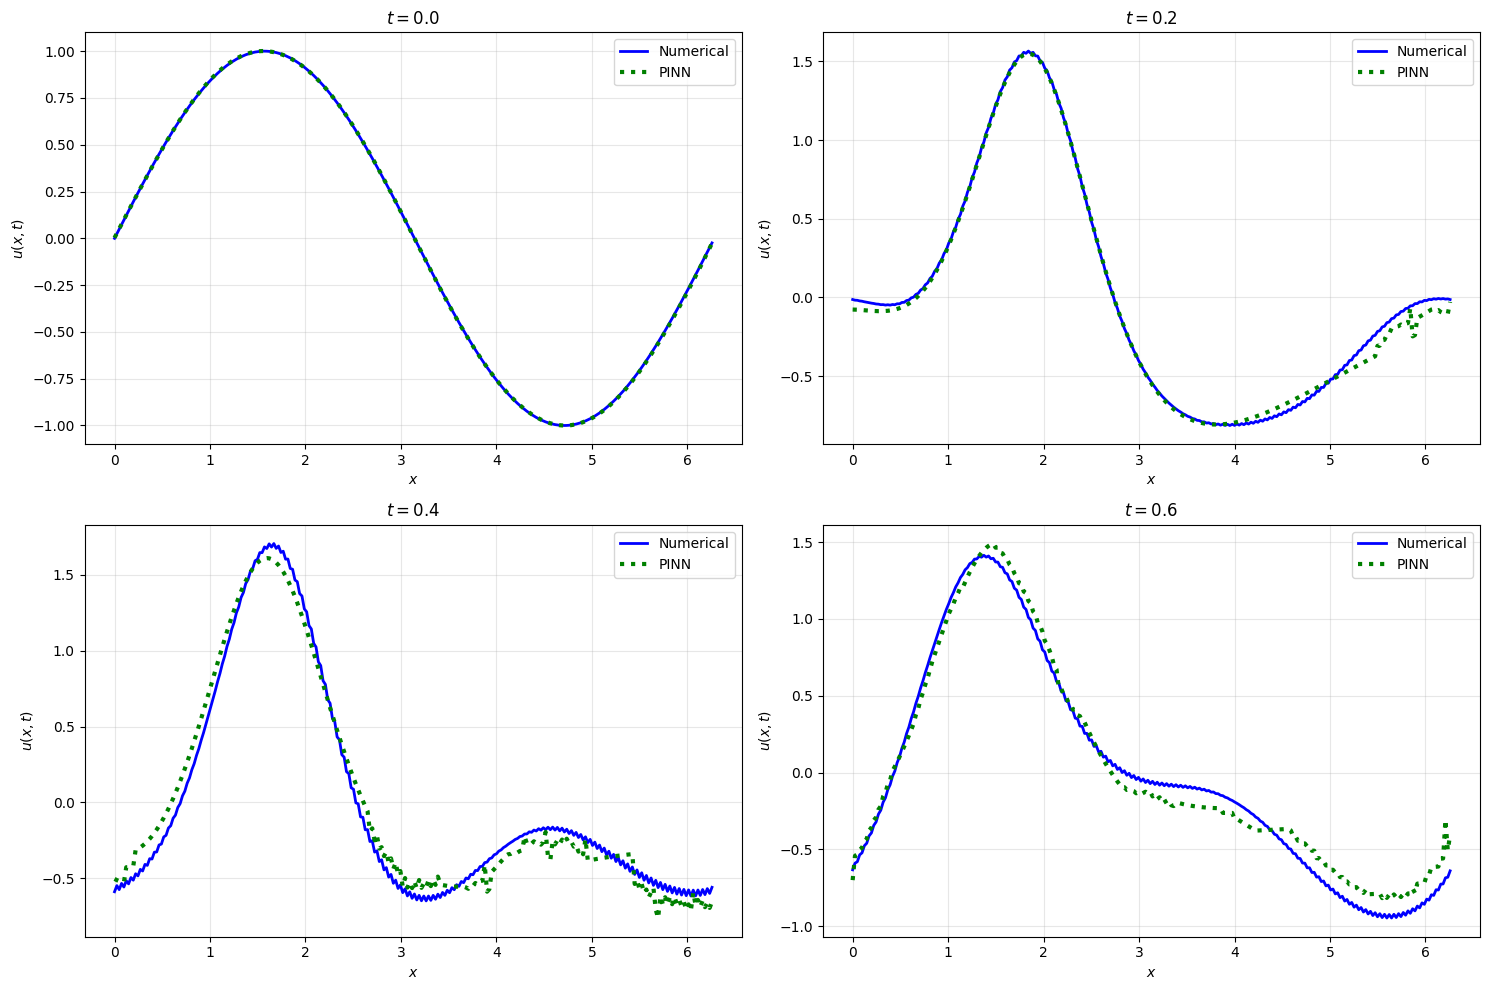

array([[ 0.00298463,  0.02729017,  0.0515518 , ..., -0.07749929,
        -0.05186788, -0.0260179 ],
       [ 0.00279909,  0.02689078,  0.05093492, ..., -0.0767707 ,
        -0.05176044, -0.02654118],
       [ 0.00264987,  0.02653126,  0.05036116, ..., -0.07588563,
        -0.05147   , -0.02685929],
       ...,
       [-0.30157393, -0.29353607, -0.28425455, ..., -0.30870348,
        -0.3073228 , -0.30592144],
       [-0.30082473, -0.29262912, -0.28319788, ..., -0.30815053,
        -0.3067559 , -0.30533969],
       [-0.70006394, -0.54171294, -0.53213483, ..., -0.30758905,
        -0.50617976, -0.40474949]])

In [19]:
load_and_visualize_edited_data()